#  Kolmogorov-Smirnov

## Định nghĩa
Kiểm định Kolmogorov-Smirnov là một phương pháp thống kê phi tham số dùng để so sánh hai phân phối xác suất. Khác với t-test yêu cầu dữ liệu phải tuân theo phân phối chuẩn, K-S Test có thể hoạt động trên bất kỳ hình dạng phân phối nào.

Trong quy trình tiền xử lý ảnh, Two-Sample K-S Test (K-S Test hai mẫu) được sử dụng để so sánh phân phối giá trị pixel của tập ảnh gốc ($X_{orig}$) và tập ảnh sau khi chuẩn hóa ($X_{norm}$).

**Giả thuyết thống kê:**
- **Giả thuyết ($H_0$):** Hai tập dữ liệu (Gốc và Đã chuẩn hóa) tuân theo cùng một phân phối xác suất.
- **Đối thuyết ($H_1$):** Hai tập dữ liệu tuân theo hai phân phối xác suất khác nhau.

## Công thức
Khi làm việc trên tập dữ liệu mẫu (các giá trị pixel rời rạc) thay vì một phương trình phân phối lý thuyết, K-S Test đo lường khoảng cách tuyệt đối lớn nhất giữa hai **Hàm phân phối tích lũy thực nghiệm (Empirical Cumulative Distribution Function - ECDF)**.

**Công thức ECDF của một mẫu dữ liệu:**

ECDF tính tỷ lệ phần trăm các điểm dữ liệu có giá trị nhỏ hơn hoặc bằng một mốc $x$ bất kỳ.

$$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}_{ \{X_i \le x\} }$$

Trong đó:

- $n$: Tổng số lượng pixel.
- $x$: giá trị ngưỡng (threshold) bất kỳ trên trục hoành đang xét (một mức cường độ sáng cụ thể).
- $\mathbf{1}_{ \{X_i \le x\} }$: Hàm chỉ thị (trả về $1$ nếu giá trị pixel $X_i \le x$, ngược lại bằng $0$).

**Thống kê K-S ($D$) được tính bằng:**

$$D = \sup_{x} |F_{orig}(x) - F_{norm}(x)|$$

Trong đó:
- $F_{orig}(x)$: Đường ECDF của tập ảnh gốc.
- $F_{norm}(x)$: Đường ECDF của tập ảnh sau chuẩn hóa.
- $\sup_{x}$ (Supremum): Chênh lệch ECDF lớn nhất. Duyệt toàn bộ các mốc $x$ trên trục hoành để tìm ra vị trí mà chênh lệch giữa hai đường ECDF là lớn nhất.
- $D$: Nằm trong khoảng $[0, 1]$. Giá trị $D$ càng lớn, hai phân phối càng khác biệt về mặt hình dáng hoặc bị dịch chuyển càng xa nhau.

## Các bước kiểm định

1. **Làm phẳng dữ liệu (Flattening):** Chuyển ảnh nhiều chiều thành một vector 1D duy nhất chứa toàn bộ các giá trị pixel.
2. **Tính ECDF:** Sắp xếp các số trong chuỗi theo thứ tự tăng dần để vẽ thành đường cong phân phối cho từng tập dữ liệu.
3. **Đo khoảng cách $D$:** Tìm vị trí mà khoảng cách chênh lệch giữa hai đường cong vừa vẽ là lớn nhất.
4. **Tính p-value:** Dựa trên trị số $D$ và kích thước mẫu để tính ra giá trị $p-value$.
5. **Kết luận:** So sánh $p-value$ với mức ý nghĩa $\alpha$ (thông thường,$\alpha = 0.05$) để quyết định bác bỏ hay chấp nhận giả thuyết $H_0$.

## Ý nghĩa của p-value
**Trường hợp $p-value \le \alpha$ (Bác bỏ $H_0$):** phân phối khác biệt đáng kể. Chuẩn hóa tạo ra biến đổi trong miền giá trị.

**Trường hợp $p-value > \alpha$ (Chấp nhận $H_0$):** Ảnh gốc và ảnh sau chuẩn hóa đều chia sẻ chung một phân phối xác suất.

# Lý thuyết và Tiêu chí Đánh giá Chuẩn hóa Ảnh
**Mục đích:** Việc chuẩn hóa không chỉ đơn thuần là đưa giá trị về một khoảng nhất định mà còn nhằm:
- **Tăng tốc độ hội tụ:** Giúp hàm mất mát (Loss Function) có hình dạng tròn trịa hơn, tránh hiện tượng "zigzag" khi cập nhật trọng số bằng Gradient Descent. Zigzag là hiện tượng mà đường đi của Gradient Descent không hội tụ nhanh về cực tiểu mà di chuyển qua lại (zigzag) giữa các hướng dốc khác nhau, khiến việc hội tụ chậm hơn rất nhiều.
- **Đưa dữ liệu về vùng tuyến tính:** Giúp các hàm kích hoạt (như Sigmoid, Tanh) không bị rơi vào vùng bão hòa (Saturation) ngay từ đầu.

## Các phương pháp chuẩn hóa phổ biến
### MinMax scaling:
Phương pháp này chuyển đổi dữ liệu về một khoảng cố định (thường là $[0, 1]$, $[-1, 1]$).

- Công thức [0, 1]: $x' = \frac{x - \min(x)}{\max(x) - \min(x) + \epsilon}$
- Công thức [-1, 1]: $x' = 2 \cdot \frac{x - \min(x)}{\max(x) - \min(x) + \epsilon} - 1$
- Đặc điểm: Giữ nguyên mối quan hệ tuyến tính giữa các pixel nhưng cực kỳ nhạy cảm với nhiễu (Outliers). Một pixel nhiễu trắng có thể làm toàn bộ ảnh sau chuẩn hóa bị tối đi đáng kể.

### Z-Score Normalization
Đưa dữ liệu về phân phối có trung bình $\mu = 0$ và độ lệch chuẩn $\sigma = 1$.

Công thức: $x' = \frac{x - \mu}{\sigma + \epsilon}$

- **Z-Score Global:** Tính $\mu$ và $\sigma$ trên toàn bộ các pixel của tất cả các kênh màu (R, G, B) gộp lại. Giúp giữ nguyên tỷ lệ cường độ giữa các kênh màu. Nếu ảnh gốc bị ám vàng, ảnh sau chuẩn hóa vẫn giữ nguyên sắc thái đó.
- **Z-Score Channel-wise:** Tính $\mu_i$ và $\sigma_i$ riêng biệt cho từng kênh màu. Đây là kỹ thuật Cân bằng trắng (White Balance) mạnh mẽ. Nó ép mỗi kênh màu phải có cùng một phân phối, giúp loại bỏ sự sai lệch màu sắc do nguồn sáng gây ra.

## Các tiêu chí đánh giá chuẩn hóa
- **Tính dịch tâm về 0:** Đưa giá trị dữ liệu về mức $0$ làm trung tâm. Điều này giúp thuật toán tối ưu (như Gradient Descent) cập nhật trọng số linh hoạt theo mọi hướng, tránh hiện tượng "zigzag" làm chậm tốc độ huấn luyện.
- **Tính đồng nhất dải giá trị:** Các giá trị sau chuẩn hóa phải nằm trong dải cho phép (ví dụ: $[0, 1]$, $[-1, 1]$, ...). Nếu dải giá trị quá lớn hay quá nhỏ, nó sẽ gây ra hiện tượng Exploding/Vanishing Gradient.
- **Bảo toàn phân phối:** Hình dạng của Histogram (vị trí các đỉnh, thung lũng) phải tương đồng với ảnh gốc. Nếu Histogram bị biến dạng mạnh hoặc xuất hiện các khoảng trống, phép chuẩn hóa đó có thể gây mất mát thông tin.

In [1]:
%matplotlib inline
import sys
import os
import matplotlib.pyplot as plt
from IPython.display import display

import visualization.comparison as comp
comp.plt.show = lambda: display(comp.plt.gcf())

sys.path.append(os.path.abspath('../src'))
from config.settings import PATH_FOLDER_IMAGE_RAW, PATH_FOLDER_IMAGE_TEST
from image.dataset import ImageDataset
# Gọi thêm NormalizationEvaluator
from image.preprocessing_normalization import Normalization, NormalizationEvaluator
from visualization.comparison import plot_normalization_comparison

dataset = ImageDataset(path=PATH_FOLDER_IMAGE_TEST)

batch_generator = dataset.load()
first_batch, first_indices = next(batch_generator)
arr = first_batch[0].copy()


🚀 PHƯƠNG PHÁP CHUẨN HÓA: minmax_01


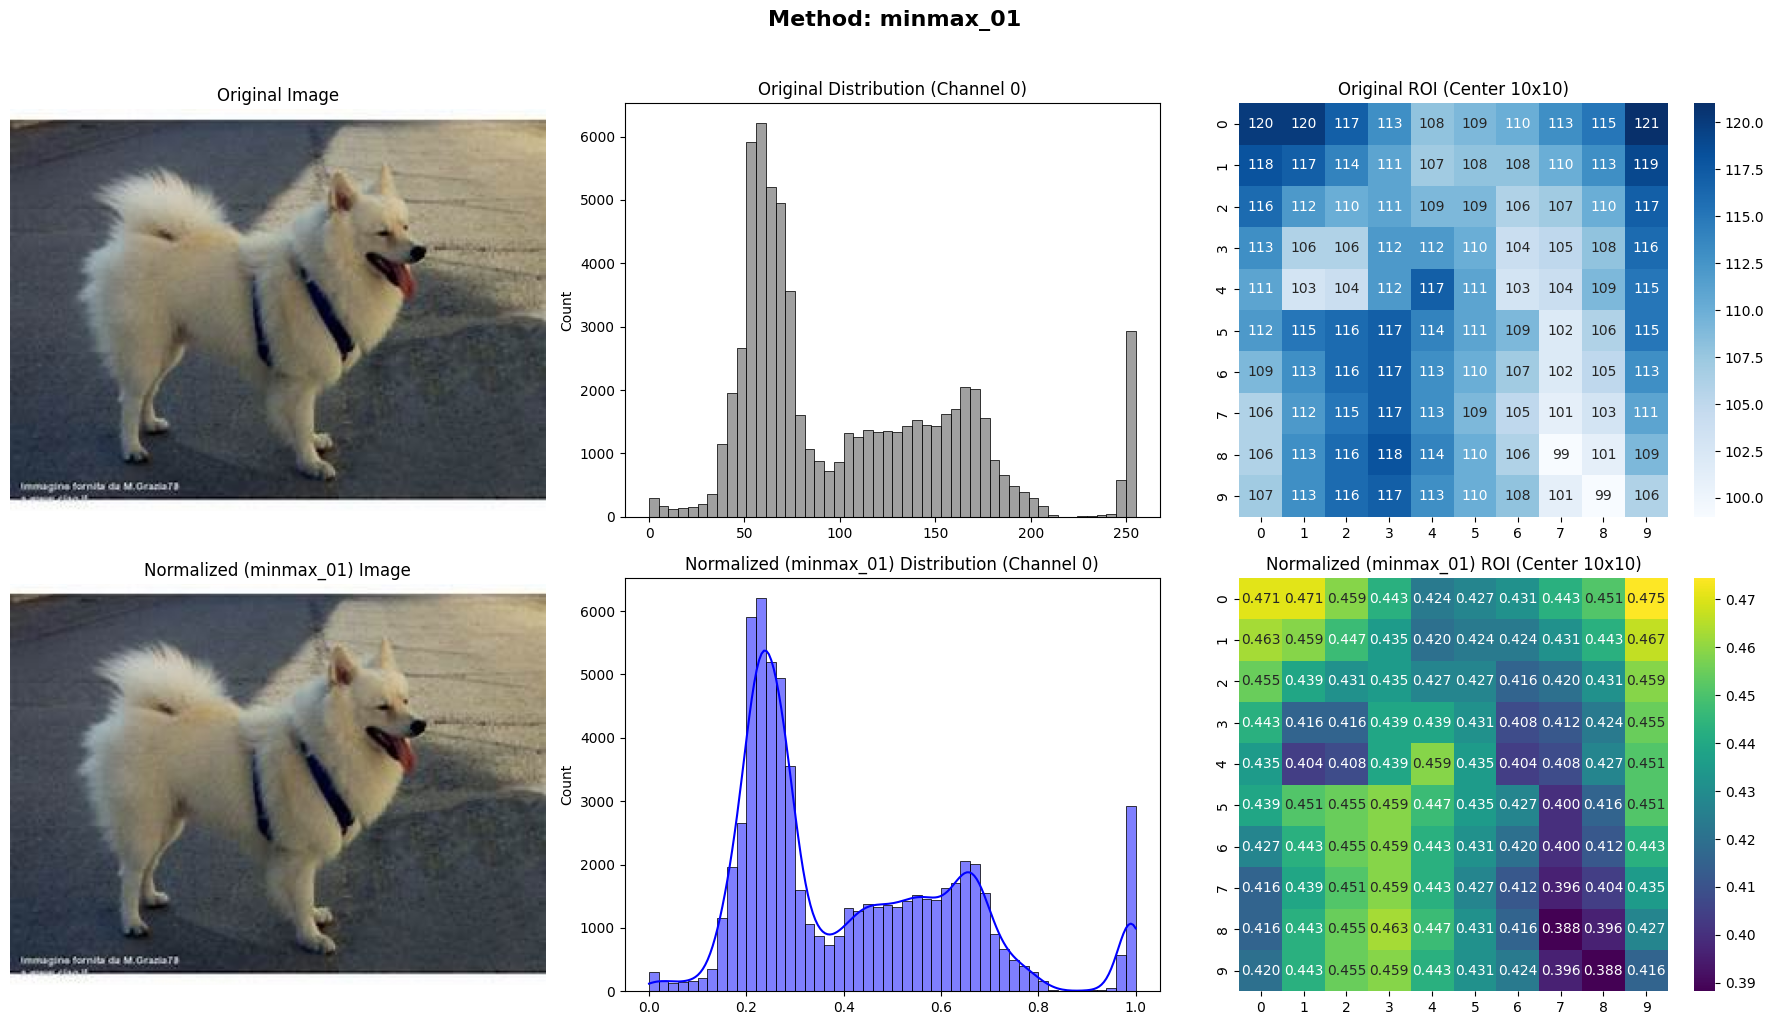


🚀 PHƯƠNG PHÁP CHUẨN HÓA: minmax_m11


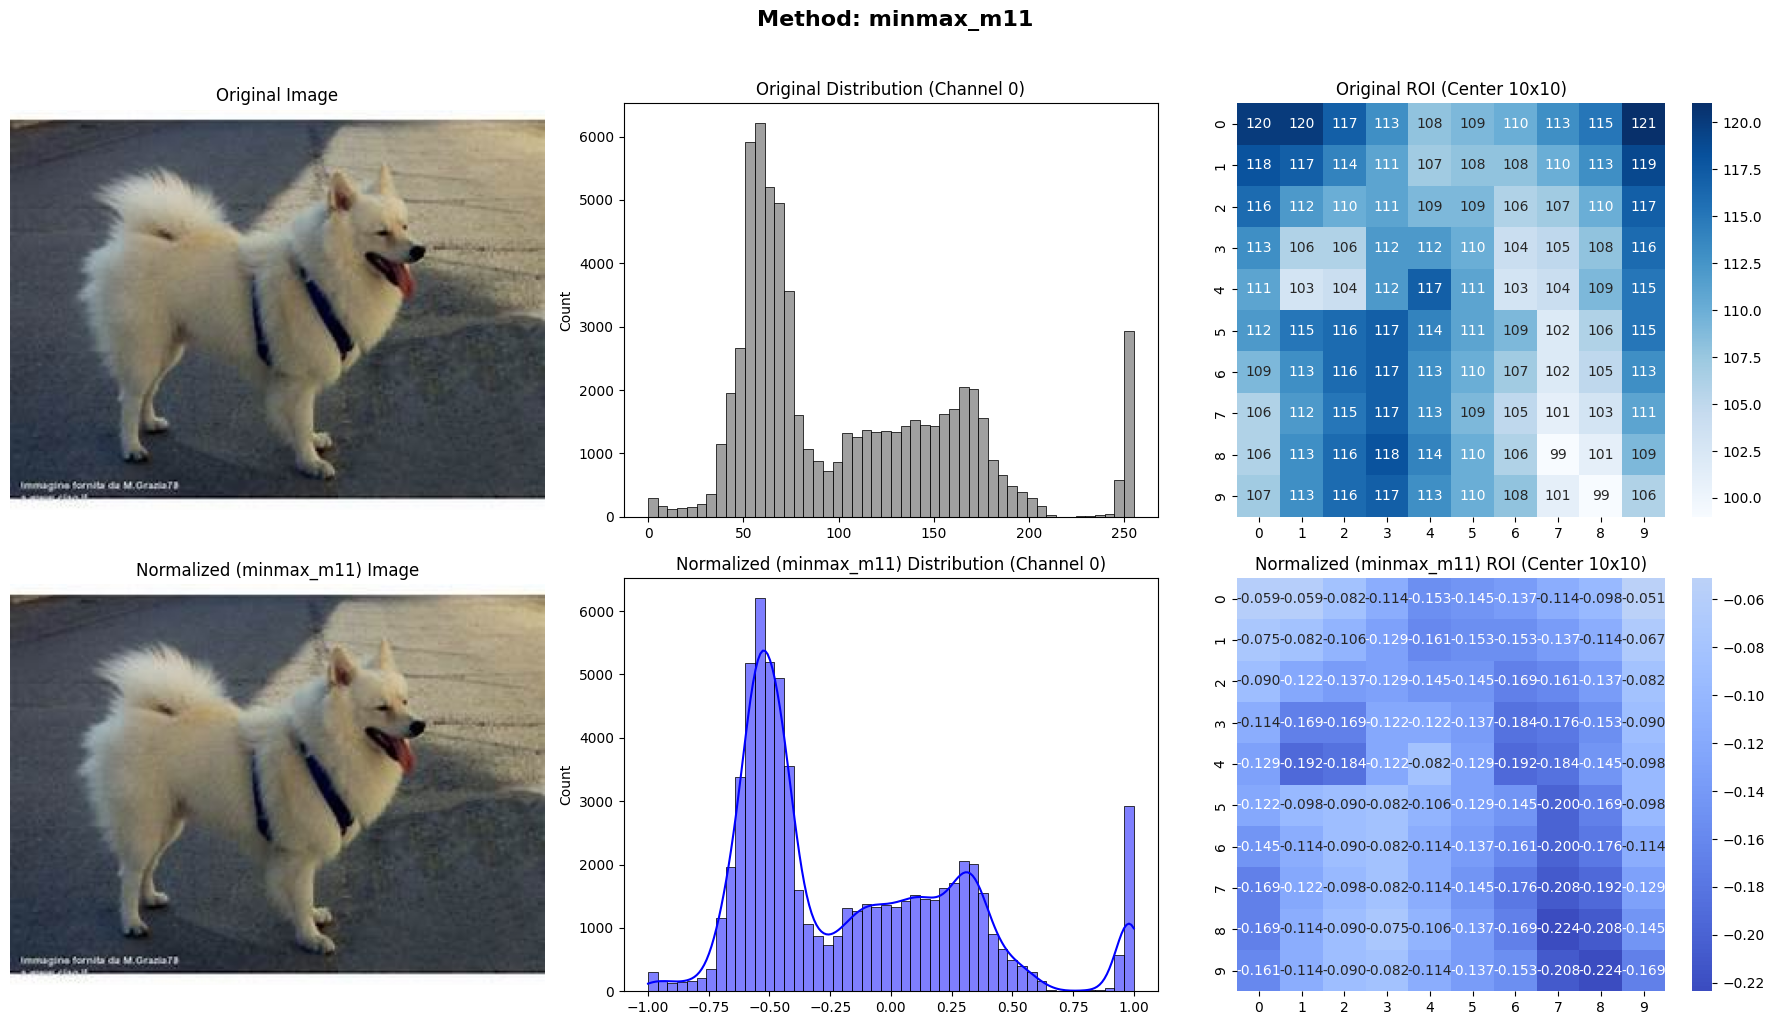


🚀 PHƯƠNG PHÁP CHUẨN HÓA: zscore_global


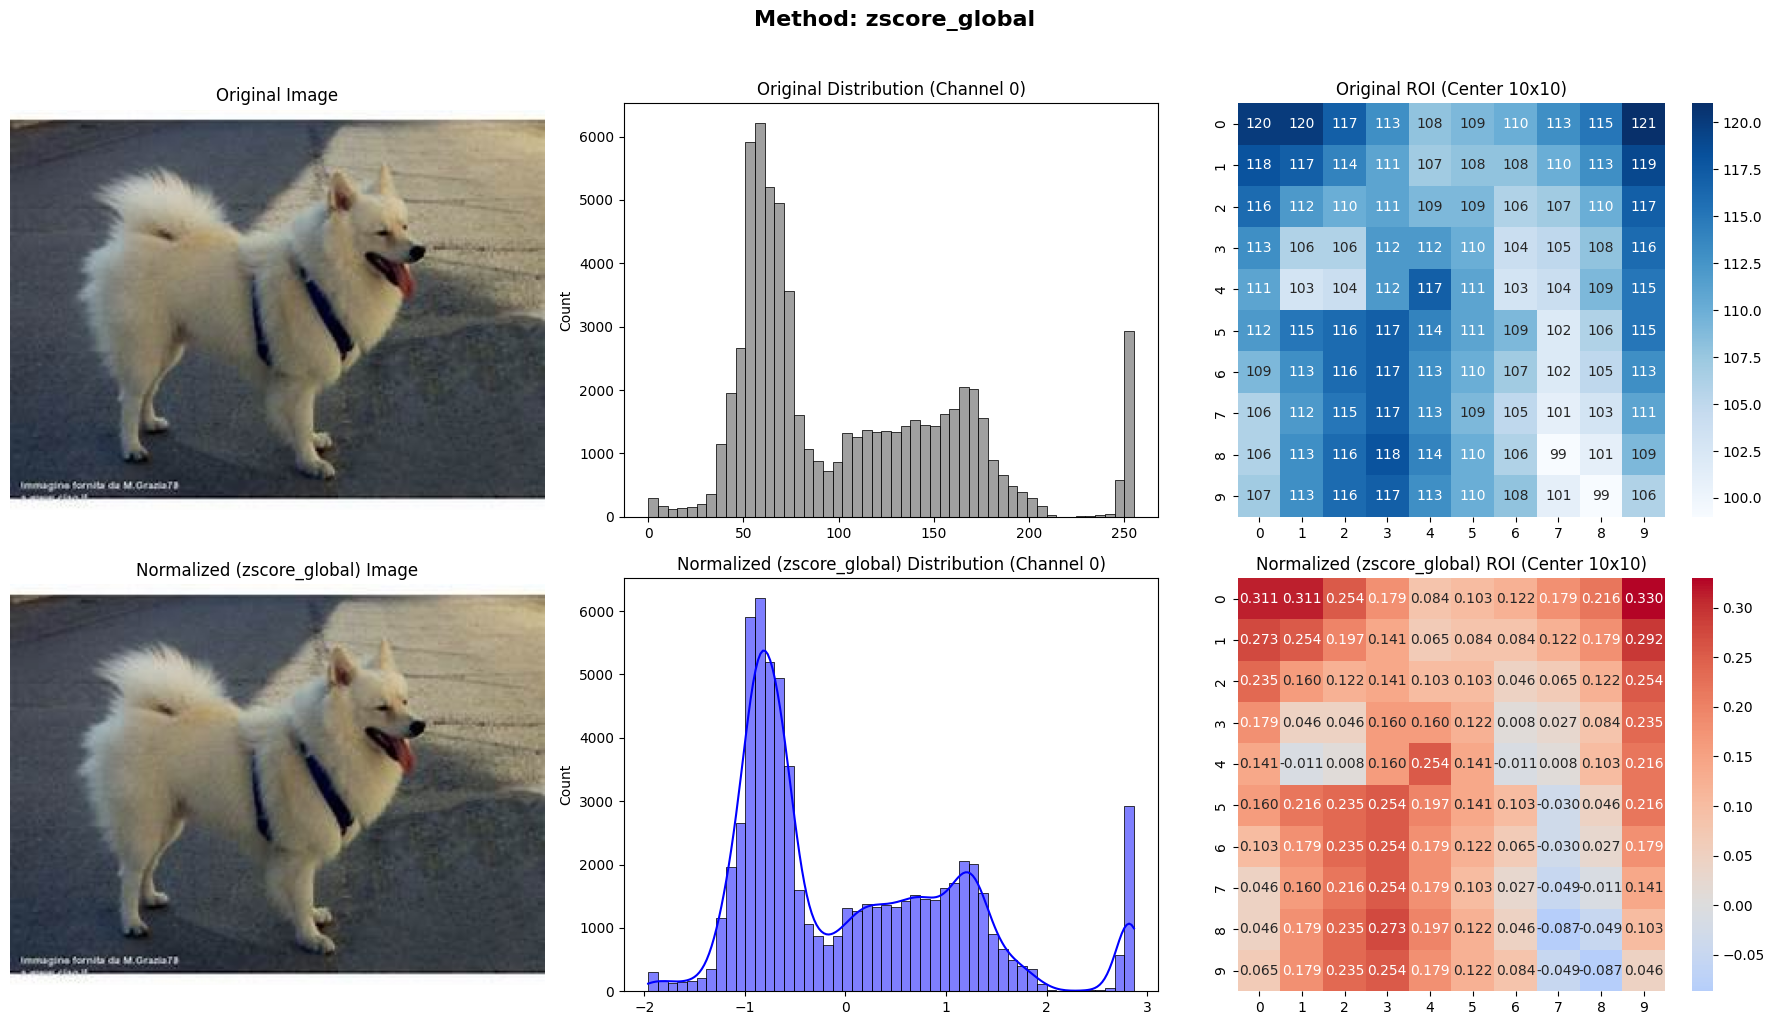


🚀 PHƯƠNG PHÁP CHUẨN HÓA: zscore_channel


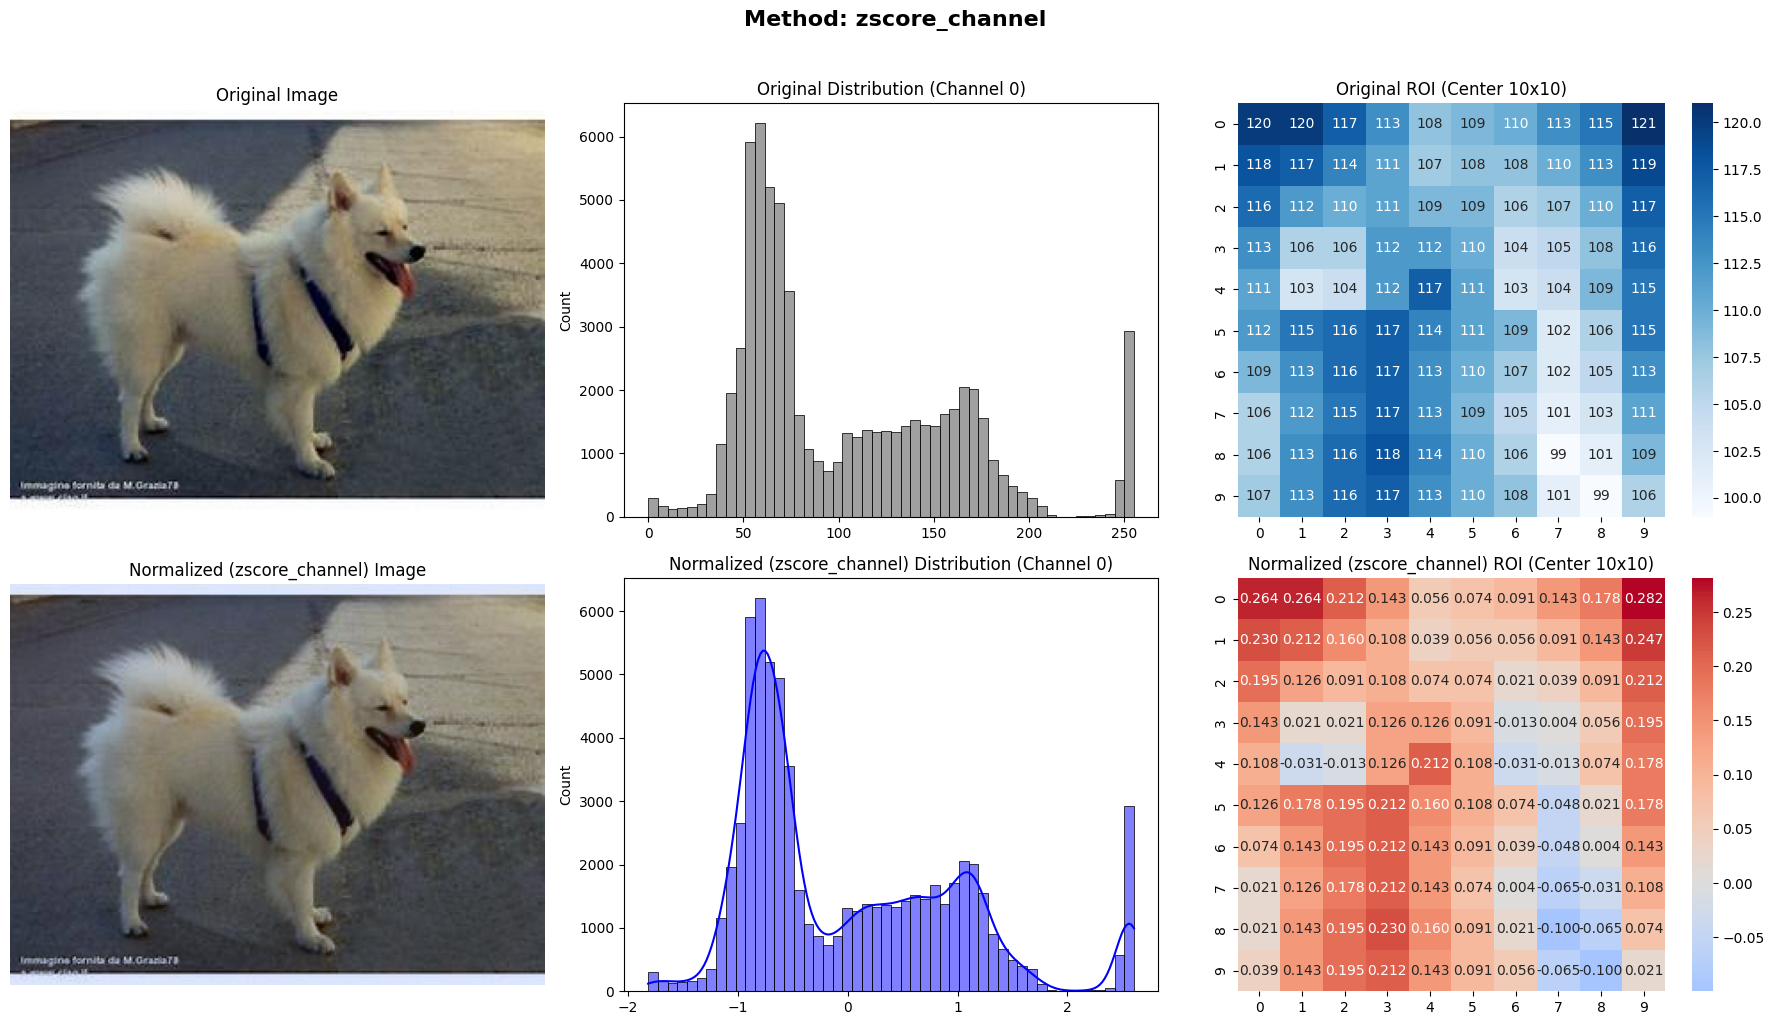

In [2]:
methods = ["minmax_01", "minmax_m11", "zscore_global", "zscore_channel"]

for method in methods:
    print(f"\n{'='*50}\n🚀 PHƯƠNG PHÁP CHUẨN HÓA: {method}\n{'='*50}")
    # Dùng class nguyên bản của nhóm để trực quan hóa 1 batch ảnh
    norm_tool = Normalization(method=method)
    
    img_normalized = norm_tool.fit_transform(arr=arr)
    plot_normalization_comparison(arr, img_normalized, method)

## Nhận xét các tiêu chí

**Tính dịch tâm về 0**

- **minmax_01:** Không có tính dịch tâm. Phân phối Histogram nằm ở phần dương của trục hoành (từ $0$ đến $1$), cho thấy không có mốc trung tâm $0$.
- **minmax_m11, zscore_global và zscore_channel:** Đều mang tính dịch tâm. Histogram có dữ liệu trải đều qua trục tung $0$. Trên biểu đồ Heatmap, giá trị $0$ được thể hiện bằng màu trắng, các pixel có giá trị âm (màu xanh) và giá trị dương (màu đỏ).

**Tính đồng nhất dải giá trị:** Nhìn chung các ảnh sau khi áp dụng các phương pháp chuẩn hóa đều cho kết quả nằm trong khoảng dự đoán.
- **minmax_01 và minmax_m11:** có các giá trị trong đoạn $[0, 1]$ và $[-1, 1]$.
- **zscore_global và zscore_channel:** Không có khoảng giá trị cố định $\min/\max$ mà tuân theo quy luật thống kê, dải giá trị phần lớn tập trung trong khoảng $[-2.5, 1.5]$.

**Bảo toàn phân phối:** Cả 4 phương pháp đều thỏa mãn tiêu chí này. Hình dáng phân phối các đỉnh và thung lũng đặc trưng của ảnh gốc được giữ nguyên trên Histogram của cả 4 kết quả. Không có hiện tượng biến dạng, gãy nứt hay xuất hiện các khoảng trống (gaps) bất thường. Điều này khẳng định các phép biến đổi là tuyến tính, không làm mất đi các đặc trưng cấu trúc ảnh.

[INFO] Đang nạp Dataset gốc...

PHƯƠNG PHÁP: minmax_01
   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: minmax_01
  - min: 0.0000
  - max: 255.0000

[EVALUATION] Train SGD Logistic Regression (minmax_01)...
[RESULT] minmax_01 (Mất 6.3s) - F1: 0.1724

   [INFO] Đang lưu từng ảnh vật lý ra: ../data/preprocessing/normalization/minmax_01 ...
   [SUCCESS] Đã xuất xong thư mục minmax_01!

PHƯƠNG PHÁP: minmax_m11
   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: minmax_m11
  - min: 0.0000
  - max: 255.0000

[EVALUATION] Train SGD Logistic Regression (minmax_m11)...
[RESULT] minmax_m11 (Mất 6.1s) - F1: 0.1746

   [INFO] Đang lưu từng ảnh vật lý ra: ../data/preprocessing/normalization/minmax_m11 ...
   [SUCCESS] Đã xuất xong thư mục minmax_m11!

PHƯƠNG PHÁP: zscore_global
   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: zscore_global
  - mean: 121.4851
  - std: 69.8753

[EVALUATION] Train SGD Logistic Regression (zscore_global)...
[RESULT] zscore_global (Mất 6.8s) - F1: 0.1871

   [INFO] Đang lưu từng ảnh vật lý ra: ../data/preprocessing/normalization/zscore_global ...
   [SUCCESS] Đã xuất xong thư mục zscore_global!

PHƯƠNG PHÁP: zscore_channel
   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: zscore_channel
  - mean: [131.90220642089844, 127.46320343017578, 105.08979797363281]
  - std: [68.21749877929688, 66.96219635009766, 71.39360046386719]

[EVALUATION] Train SGD Logistic Regression (zscore_channel)...
[RESULT] zscore_channel (Mất 7.8s) - F1: 0.1796

   [INFO] Đang lưu từng ảnh vật lý ra: ../data/preprocessing/normalization/zscore_channel ...
   [SUCCESS] Đã xuất xong thư mục zscore_channel!

[INFO] ĐANG VẼ BIỂU ĐỒ TỐC ĐỘ HỘI TỤ (LEARNING CURVE)...


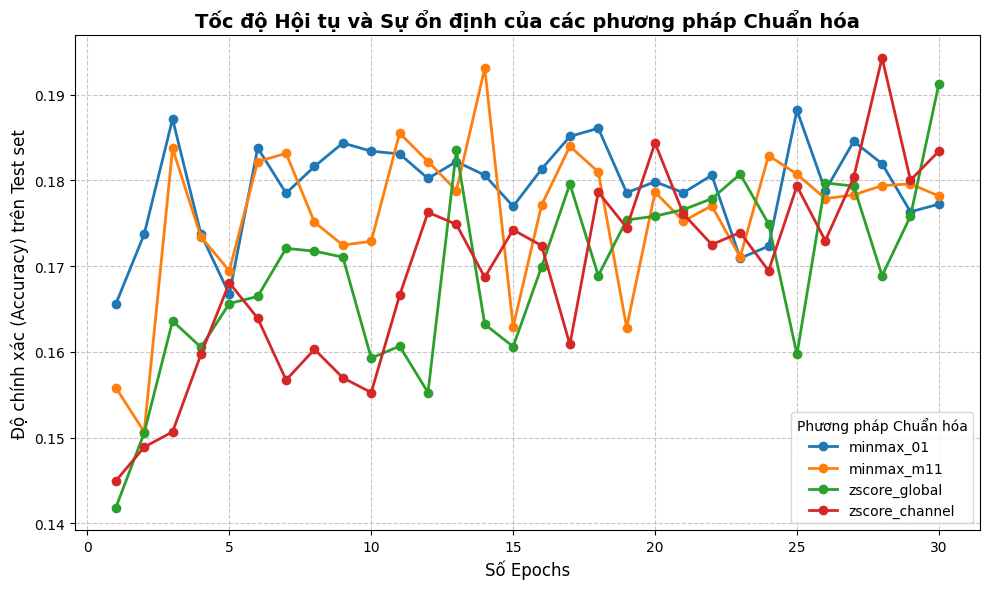

In [3]:
import sys, os, warnings
warnings.filterwarnings("ignore")

if os.path.abspath('../src') not in sys.path:
    sys.path.append(os.path.abspath('../src'))

from image.dataset import ImageDataset
# Sử dụng Evaluator để không đụng vào code chạy thật
from image.preprocessing_normalization import NormalizationEvaluator
from visualization.evaluation import plot_normalization_learning_curves
from config.settings import PATH_FOLDER_IMAGE_RAW

print("[INFO] Đang nạp Dataset gốc...")
dataset = ImageDataset(path=PATH_FOLDER_IMAGE_RAW)

methods = ["minmax_01", "minmax_m11", "zscore_global", "zscore_channel"]

final_metrics = []
learning_curves_dict = {}

for method in methods:
    print(f"\n{'='*50}\nPHƯƠNG PHÁP: {method}\n{'='*50}")
    # Gọi Class Evaluator
    norm_tool = NormalizationEvaluator(method=method)
    
    norm_tool.run(dataset)
    metrics, epoch_curve = norm_tool.evaluation(n_repeats=3, max_epochs=30)
    norm_tool.save_images()
    
    learning_curves_dict[method] = epoch_curve
    metrics["Method"] = method
    final_metrics.append(metrics)

print("\n[INFO] ĐANG VẼ BIỂU ĐỒ TỐC ĐỘ HỘI TỤ (LEARNING CURVE)...")
plot_normalization_learning_curves(learning_curves_dict)

## Tổng kết thực nghiệm: Đánh giá tiền xử lý Normalization

### 1. Mục tiêu và lợi ích của việc chuẩn hóa dữ liệu
Trong không gian màu gốc (ví dụ RGB), giá trị pixel dao động từ 0 đến 255. Việc đưa các giá trị lớn này trực tiếp vào mô hình (như Logistic Regression sử dụng Gradient Descent) sẽ gây ra hiện tượng mất cân bằng trọng số, khiến thuật toán tối ưu phải mất rất nhiều thời gian để dò dẫm tìm điểm cực tiểu, hoặc thậm chí bị lệch hướng.
* **Mục tiêu:** Đưa toàn bộ các chiều dữ liệu về cùng một hệ quy chiếu (cùng thang đo).
* **Lợi ích:** Giúp bề mặt hàm mất mát trở nên tròn đều hơn, qua đó thuật toán tối ưu hóa có thể hội tụ nhanh hơn, giảm hiện tượng dao động và tránh được rủi ro bùng nổ đạo hàm.

### 2. Phân tích cặp phương pháp 1: `minmax_01` vs `minmax_m11`
Hai phương pháp này đều ép cứng dữ liệu vào một khoảng cố định bằng công thức tuyến tính.
* **Mục đích scale và Sự khác biệt:**
  * `minmax_01` ép giá trị về khoảng **[0, 1]**. Nhược điểm lớn nhất của nó là toàn bộ dữ liệu đầu vào đều mang dấu dương. Trong Gradient Descent, điều này khiến các trọng số được cập nhật cùng một hướng (cùng tăng hoặc cùng giảm), tạo ra các bước đi zigzag rất kém hiệu quả.
  * `minmax_m11` ép giá trị về khoảng **[-1, 1]** (Zero-centered data). Việc đưa mean về gần số 0 giúp dữ liệu có cả giá trị âm và dương, giải quyết triệt để sự "thiên lệch" của `minmax_01`.
* **Kết quả thực nghiệm:** F1-score của `minmax_m11` (0.1746) nhỉnh hơn `minmax_01` (0.1724). Đường cong hội tụ của `minmax_01` (màu xanh dương) trên biểu đồ thường có những cú rớt đột ngột, trong khi `minmax_m11` (màu cam) cân bằng hơn ở các epoch cuối nhờ lợi thế của Zero-centered.

### 3. Phân tích cặp phương pháp 2: `zscore_global` vs `zscore_channel`
Z-score không ép cứng dữ liệu vào một giới hạn cố định mà chuẩn hóa dựa trên phân phối thống kê (đưa Mean về 0 và độ lệch chuẩn Std về 1).
* **Mục đích scale và Sự khác biệt:**
  * `zscore_global` tính một Mean (121.48) và một Std (69.87) chung cho toàn bộ bức ảnh. Việc này giúp giữ nguyên **tỷ lệ tương đối** giữa 3 kênh R, G, B. (Tức là màu cam vẫn là màu cam).
  * `zscore_channel` tính Mean và Std riêng cho từng kênh (Ví dụ: Kênh R bị trừ đi 131.9, nhưng kênh B chỉ bị trừ đi 105.0).
* **Giải thích sự biến đổi (Vì sao Global lại thắng Channel?):** Kết quả F1 của `zscore_global` là cao nhất (0.1871), trong khi `zscore_channel` bị rớt xuống (0.1796). Lý do cốt lõi là việc scale độc lập từng kênh R-G-B đã vô tình làm **biến dạng màu sắc gốc** của bức ảnh. Trong bài toán phân loại động vật, màu sắc nguyên bản (ví dụ màu vàng của lông chó) là đặc trưng sống còn. `zscore_global` là phương pháp duy nhất vừa giúp mô hình tối ưu nhanh (Zero-centered), vừa **bảo toàn được 100% tỷ lệ pha trộn màu sắc tự nhiên**, do đó nó đạt hiệu suất cao nhất.

### 4. Đánh giá tốc độ hội tụ và sự dao động qua biểu đồ Epochs
Dựa vào biểu đồ "tốc độ hội tụ và sự ổn định", ta có thể rút ra:
* **Sự dao động:** Nhìn chung, cả 4 phương pháp đều bị dao động (zigzag) khá mạnh. Nguyên nhân là do chúng ta sử dụng `SGDClassifier` trên một không gian đã bị nén cực gắt bởi PCA (còn 50 chiều). Không gian này chứa rất nhiều nhiễu, khiến mỗi mini-batch đưa vào mô hình đều gây ra sự xáo trộn nhỏ trong trọng số.
* **Tốc độ hội tụ:** * Các phương pháp MinMax (xanh dương, cam) có xu hướng đạt đỉnh "ảo" rất sớm (ngay tại epoch 3-4) nhưng sau đó không thể duy trì và tiếp tục nhảy múa loạn xạ.
  * Phương pháp `zscore_global` (màu xanh lá) bắt đầu ở mức thấp (~0.14) nhưng có xu hướng leo dốc đều đặn và thiết lập được một nền tảng ổn định hơn ở khu vực epoch 15-25, đạt được điểm cân bằng tốt nhất trước khi test.

### 5. Kết luận: Chọn phương pháp tốt nhất
Từ các phân tích trên, **`zscore_global` (Chuẩn hóa Z-Score toàn cục)** được chọn là kích thước/phương pháp tiền xử lý tốt nhất cho bộ dữ liệu này.
* **Lý do lựa chọn:**
  1. **Thống kê:** Nó đưa dữ liệu về dạng Zero-centered (Mean = 0), giúp thuật toán SGD tối ưu mượt mà và thoát khỏi bẫy thiên lệch hướng của MinMax [0, 1].
  2. **Toán học:** Nó không bóp méo tỷ lệ pha màu tự nhiên của ảnh động vật như `zscore_channel`.
  3. **Thực chứng:** Nó mang lại chỉ số tổng hợp F1-Score cao nhất toàn bộ thí nghiệm (0.1871) và duy trì được đà tăng trưởng độ chính xác chắc chắn nhất trên đồ thị hội tụ.